# Demo: Bowl Detection using Annotations

This notebook processes images from the bowl dataset and uses the annotations JSON file to determine which objects to detect using SAM3.

For each selected image, we:
1. Load the annotations from the JSON file
2. Extract the categories/labels that are annotated for that image
3. Use those categories as prompts for SAM3 detection
4. Visualize the results


In [150]:
import cv2
import numpy as np
from pathlib import Path
import json
import random
from openfilter.filter_runtime.filter import Frame
from filter_sam3_detector.filter import FilterSAM3Detector
import matplotlib.pyplot as plt
from collections import defaultdict


## Configuration


In [151]:
# Configuration
annotations_path = Path("/home/leandrobmarinho/datasets/bowl/sg-bowl-ds-cum-2025-12-23/multilabel_datasets/annotations.json")
images_folder = Path("/home/leandrobmarinho/datasets/bowl/sg-bowl-ds-cum-2025-12-23/data")
confidence_threshold = 0.2  # Minimum confidence threshold for SAM3 detector
min_score_filter = 0.3  # Minimum score to keep in final results

# Size validation parameters
MAX_BOWL_SIZE_RATIO = 0.5  # Maximum size relative to image (50% = too big, likely bowl)
# Largest ingredients: salmon and avocado (can be larger)
LARGE_INGREDIENTS = ["miso_glazed_steelhead", "avocado"]
# Rest are cubes (should be smaller)
CUBE_INGREDIENTS = ["hard_boiled_egg", "roasted_tofu", "blackened_chicken", 
                    "roasted_chicken", "caramelized_garlic_steak", "warm_portobello_mix"]

# List of ingredients/categories to find images for
# Will select the first image that contains each ingredient
# Only items in this list will be processed (commented lines are ignored)
INGREDIENTS_TO_FIND = [
    "avocado",
    "hard_boiled_egg",
    "miso_glazed_steelhead",    
    "blackened_chicken",
    "roasted_chicken",
    "caramelized_garlic_steak",    
    "roasted_tofu",
    "warm_portobello_mix",
]

# Filter to only process active ingredients (non-commented items)
# In Python, commented lines are automatically excluded, but this ensures only valid strings are processed
INGREDIENTS_TO_FIND = [item for item in INGREDIENTS_TO_FIND if isinstance(item, str) and item.strip()]

# Map category names to detection prompts (if needed)
# Some categories might need different prompts for SAM3
# This is the ONLY place you need to define mappings - reverse mapping is auto-generated
CATEGORY_PROMPT_MAPPING = {
    "caramelized_garlic_steak": "steak",
    "hard_boiled_egg": "egg",
    "miso_glazed_steelhead": "cooked salmon fillet",
    "roasted_tofu": "tofu cube",  # Changed to differentiate from carrot
    "warm_portobello_mix": "dark mushroom mix",
    "blackened_chicken": "chicken chunks",
    "roasted_chicken": "chicken chunks",
    "avocado": "avocado",
    # Categories without mapping use their original name (no need to add them here)
}

# Auto-generate reverse mapping from CATEGORY_PROMPT_MAPPING
# For prompts that map to multiple categories (like "chicken"), we'll handle them specially
PROMPT_TO_CATEGORY_MAPPING = {}
prompt_to_categories = {}  # Track which categories map to each prompt

for category, prompt in CATEGORY_PROMPT_MAPPING.items():
    if prompt not in prompt_to_categories:
        prompt_to_categories[prompt] = []
    prompt_to_categories[prompt].append(category)

# Build reverse mapping
# If a prompt maps to only one category, use that category
# If a prompt maps to multiple categories, set to None (will be determined by context)
for prompt, categories in prompt_to_categories.items():
    if len(categories) == 1:
        PROMPT_TO_CATEGORY_MAPPING[prompt] = categories[0]
    else:
        # Multiple categories map to same prompt - will be determined by context
        PROMPT_TO_CATEGORY_MAPPING[prompt] = None

print("Category to Prompt Mapping:")
for cat, prompt in sorted(CATEGORY_PROMPT_MAPPING.items()):
    print(f"  {cat} -> {prompt}")
print("\nAuto-generated Prompt to Category Mapping:")
for prompt, cat in sorted(PROMPT_TO_CATEGORY_MAPPING.items()):
    if cat is None:
        # Show which categories this prompt can map to
        cats = prompt_to_categories[prompt]
        print(f"  {prompt} -> None (context-dependent: {', '.join(cats)})")
    else:
        print(f"  {prompt} -> {cat}")

print(f"Annotations file: {annotations_path}")
print(f"Images folder: {images_folder}")
print(f"Confidence threshold: {confidence_threshold}")
print(f"Min score filter: {min_score_filter}")
print(f"Ingredients to find: {INGREDIENTS_TO_FIND}")


Category to Prompt Mapping:
  avocado -> avocado
  blackened_chicken -> chicken chunks
  caramelized_garlic_steak -> steak
  hard_boiled_egg -> egg
  miso_glazed_steelhead -> cooked salmon fillet
  roasted_chicken -> chicken chunks
  roasted_tofu -> tofu cube
  warm_portobello_mix -> dark mushroom mix

Auto-generated Prompt to Category Mapping:
  avocado -> avocado
  chicken chunks -> None (context-dependent: blackened_chicken, roasted_chicken)
  cooked salmon fillet -> miso_glazed_steelhead
  dark mushroom mix -> warm_portobello_mix
  egg -> hard_boiled_egg
  steak -> caramelized_garlic_steak
  tofu cube -> roasted_tofu
Annotations file: /home/leandrobmarinho/datasets/bowl/sg-bowl-ds-cum-2025-12-23/multilabel_datasets/annotations.json
Images folder: /home/leandrobmarinho/datasets/bowl/sg-bowl-ds-cum-2025-12-23/data
Confidence threshold: 0.2
Min score filter: 0.3
Ingredients to find: ['avocado', 'hard_boiled_egg', 'miso_glazed_steelhead', 'blackened_chicken', 'roasted_chicken', 'carame

In [152]:
# Load annotations JSON file
print("Loading annotations file...")
with open(annotations_path, 'r') as f:
    annotations_data = json.load(f)

# Create mappings
categories_dict = {cat['id']: cat['name'] for cat in annotations_data['categories']}
images_dict = {img['id']: img for img in annotations_data['images']}

# Group annotations by image_id
annotations_by_image = defaultdict(list)
for ann in annotations_data['annotations']:
    annotations_by_image[ann['image_id']].append(ann)

print(f"Loaded {len(annotations_data['categories'])} categories")
print(f"Loaded {len(annotations_data['images'])} images")
print(f"Loaded {len(annotations_data['annotations'])} annotations")
print(f"\nCategories: {[cat['name'] for cat in annotations_data['categories']]}")


Loading annotations file...
Loaded 8 categories
Loaded 11317 images
Loaded 14094 annotations

Categories: ['avocado', 'blackened_chicken', 'caramelized_garlic_steak', 'hard_boiled_egg', 'miso_glazed_steelhead', 'roasted_chicken', 'roasted_tofu', 'warm_portobello_mix']


In [153]:
# Select images from the dataset
# Get all image files and shuffle for random selection
all_image_files = list(images_folder.glob("*.png"))
random.shuffle(all_image_files)  # Shuffle for random selection
print(f"\nFound {len(all_image_files)} image files in dataset (shuffled for random selection)")

# Select first image for each ingredient in the list
selected_images = []
selected_image_ids = set()  # Track selected images to avoid duplicates

for ingredient in INGREDIENTS_TO_FIND:
    # Find first image that contains this ingredient
    found = False
    for img_file in all_image_files:
        if found:
            break
        
        # Skip if already selected
        if img_file in [img['path'] for img in selected_images]:
            continue
        
        # Find this image in the annotations
        img_filename = img_file.name
        img_info = None
        for img_id, img_data in images_dict.items():
            if img_data['file_name'] == img_filename:
                img_info = img_data
                break
        
        if img_info:
            # Get annotations for this image
            image_id = img_info['id']
            
            # Skip if already selected
            if image_id in selected_image_ids:
                continue
            
            image_annotations = annotations_by_image.get(image_id, [])
            
            # Get unique categories for this image
            category_ids = set(ann['category_id'] for ann in image_annotations)
            categories = [categories_dict[cid] for cid in category_ids]
            
            # Check if this image contains the ingredient we're looking for
            if ingredient in categories:
                # Map categories to prompts
                prompts = []
                for cat in categories:
                    prompt = CATEGORY_PROMPT_MAPPING.get(cat, cat)
                    if prompt not in prompts:
                        prompts.append(prompt)
                
                selected_images.append({
                    "path": img_file,
                    "image_info": img_info,
                    "image_id": image_id,
                    "annotations": image_annotations,
                    "categories": categories,
                    "prompts": prompts,
                    "target_ingredient": ingredient  # Track which ingredient this was selected for
                })
                selected_image_ids.add(image_id)
                found = True
                
                print(f"\nSelected for '{ingredient}': {img_filename}")
                print(f"  Image ID: {image_id}")
                print(f"  Annotated categories: {categories}")
                print(f"  Detection prompts: {prompts}")
                print(f"  Number of annotations: {len(image_annotations)}")
    
    if not found:
        print(f"\nWarning: No image found containing '{ingredient}'")

print(f"\nTotal selected: {len(selected_images)} images")



Found 10755 image files in dataset (shuffled for random selection)

Selected for 'avocado': 1144_1762383918219.png
  Image ID: 354
  Annotated categories: ['avocado', 'blackened_chicken']
  Detection prompts: ['avocado', 'chicken chunks']
  Number of annotations: 2

Selected for 'hard_boiled_egg': 001104_frame_000001_ts1764280353_148_count02.png
  Image ID: 9173
  Annotated categories: ['avocado', 'hard_boiled_egg']
  Detection prompts: ['avocado', 'egg']
  Number of annotations: 2

Selected for 'miso_glazed_steelhead': 000568_frame_000151_ts1764036726_070_count05.png
  Image ID: 6554
  Annotated categories: ['avocado', 'miso_glazed_steelhead']
  Detection prompts: ['avocado', 'cooked salmon fillet']
  Number of annotations: 2

Selected for 'blackened_chicken': 152_1762877558349.png
  Image ID: 1664
  Annotated categories: ['blackened_chicken']
  Detection prompts: ['chicken chunks']
  Number of annotations: 1

Selected for 'roasted_chicken': 27_1762530912639.png
  Image ID: 570
  Ann

## Initialize SAM3 Detector


In [154]:
# Initialize detector (will update prompt for each object)
detector = FilterSAM3Detector({
    "text_prompt": "Avocado scoop",  # Initial prompt, will be updated
    "confidence_threshold": confidence_threshold,
    "device": "cuda",
    "visualize": False,
    "output_label": "detections",
})

detector.setup(detector.config)
print("SAM3 Detector initialized successfully!")


2025-12-29 15:12:30.970 1936549 INFO     [Filter] Raw subject data export is DISABLED (set OPENLINEAGE_EXPORT_RAW_DATA=true to enable)
2025-12-29 15:12:30.973 1936549 INFO     FilterSAM3Detector(config={'text_prompt': 'Avocado scoop', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-X3zNRf'})
2025-12-29 15:12:30.990 1936549 INFO     ==========================================
2025-12-29 15:12:30.992 1936549 INFO     FilterSAM3Detector setup: {'text_prompt': 'Avocado scoop', 'confidence_threshold': 0.2, 'device': 'cuda', 'visualize': False, 'output_label': 'detections', 'id': 'FilterSAM3Detector-X3zNRf'}
2025-12-29 15:12:30.995 1936549 INFO     ==========================================
2025-12-29 15:12:30.998 1936549 INFO     Using device: cuda
2025-12-29 15:12:30.999 1936549 INFO     Loading SAM3 model on device: cuda
2025-12-29 15:12:31.002 1936549 INFO     Found BPE file at: /home/leandrobmarinho/datasets/filte

SAM3 Detector initialized successfully!


## Process Images


In [155]:
def process_image_for_detection(img_path, prompts_to_detect, original_categories, 
                                custom_confidence=None, custom_min_score=None):
    """Process a single image and detect all specified objects using SAM3.
    
    Args:
        img_path: Path to the image
        prompts_to_detect: List of prompts to use for SAM3 detection
        original_categories: List of original category names from annotations
        custom_confidence: Optional custom confidence threshold (default: uses global)
        custom_min_score: Optional custom min_score filter (default: uses global)
    
    Returns:
        img_bgr: Image in BGR format
        detections: List of detections with original category names as labels (filtered by size)
        filtered_count: Number of detections filtered out due to size (too large = likely bowl)
    """
    # Load image
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        print(f"Warning: Could not load image: {img_path}")
        return None, []
    
    # Create mapping from prompt to original category
    # For prompts that map to multiple categories, use the one present in original_categories
    prompt_to_original = {}
    for prompt in prompts_to_detect:
        # Check reverse mapping
        if prompt in PROMPT_TO_CATEGORY_MAPPING:
            mapped_category = PROMPT_TO_CATEGORY_MAPPING[prompt]
            if mapped_category is None:  # Multiple categories map to this prompt
                # Find which category from the possible ones is in original_categories
                possible_categories = prompt_to_categories[prompt]
                found_category = None
                for cat in possible_categories:
                    if cat in original_categories:
                        found_category = cat
                        break
                # Use first possible category as default if none found
                prompt_to_original[prompt] = found_category if found_category else possible_categories[0]
            else:
                prompt_to_original[prompt] = mapped_category
        else:
            # No mapping, use prompt as-is
            prompt_to_original[prompt] = prompt
    
    # Process each object type separately
    all_detections = []
    
    for prompt in prompts_to_detect:
        # Update detector prompt for this object
        detector.cfg.text_prompt = prompt
        detector.text_prompt = prompt
        
        # Create Frame object
        frame = Frame(image=img_bgr, format="BGR")
        frames_dict = {"frames": frame}
        
        # Run detection
        detected = detector.process(frames_dict)
        
        # Extract detections and label them with ORIGINAL category name
        if detected:
            for topic, frame in detected.items():
                dets = frame.data.get('meta', {}).get('detections', [])
                for det in dets:
                    labeled_det = det.copy()
                    # Use original category name, not the prompt
                    labeled_det['label'] = prompt_to_original[prompt]
                    all_detections.append(labeled_det)
                break
    
    # Filter detections by minimum score (use custom if provided)
    score_threshold = custom_min_score if custom_min_score is not None else min_score_filter
    filtered_detections = [det for det in all_detections if det.get('score', 0.0) >= score_threshold]
    
    # Filter out detections that are too large (likely the bowl itself)
    h, w = img_bgr.shape[:2]
    image_area = h * w
    size_filtered_detections = []
    filtered_count = 0
    
    for det in filtered_detections:
        box = det.get('box', [])
        if len(box) == 4:
            x1, y1, x2, y2 = box
            det_width = x2 - x1
            det_height = y2 - y1
            det_area = det_width * det_height
            area_ratio = det_area / image_area
            
            label = det.get('label', 'unknown')
            
            # Check if detection is too large (likely bowl)
            if area_ratio > MAX_BOWL_SIZE_RATIO:
                filtered_count += 1
                continue  # Skip this detection - too large (likely bowl)
            
            # Additional validation: cube ingredients should not be too large
            if label in CUBE_INGREDIENTS:
                # Cubes should be relatively small compared to large ingredients
                # If a cube is larger than 30% of image, it's suspicious
                if area_ratio > 0.3:
                    filtered_count += 1
                    continue  # Skip - cube too large
            
            size_filtered_detections.append(det)
    
    return img_bgr, size_filtered_detections, filtered_count

# Process all selected images
results = []

print("Processing images...\n")
for img_data in selected_images:
    img_path = img_data["path"]
    prompts = img_data["prompts"]
    categories = img_data["categories"]
    
    print(f"Processing: {img_path.name}")
    print(f"  Annotated categories: {categories}")
    print(f"  Using prompts: {prompts}")
    
    # Try detection with initial thresholds
    img_bgr, detections, filtered_count = process_image_for_detection(img_path, prompts, categories)
    
    if img_bgr is not None:
        if filtered_count > 0:
            print(f"  ⚠️  Filtered out {filtered_count} detection(s) that were too large (likely bowl)")
        
        detected_labels = set(det.get('label', 'unknown') for det in detections)
        
        # Validate that all annotated categories have at least 1 bounding box
        missing_categories = []
        for category in categories:
            if category not in detected_labels:
                missing_categories.append(category)
        
        # If missing detections, try again with lower thresholds
        retry_count = 0
        max_retries = 3
        current_min_score = min_score_filter
        current_confidence = confidence_threshold
        
        while missing_categories and retry_count < max_retries:
            retry_count += 1
            # Progressively lower thresholds
            current_min_score = max(0.0, current_min_score - 0.1)
            current_confidence = max(0.05, current_confidence - 0.05)
            
            print(f"  🔄 Retry {retry_count}/{max_retries}: Trying with lower thresholds")
            print(f"     min_score: {current_min_score:.2f}, confidence: {current_confidence:.2f}")
            
            # Update detector confidence threshold
            detector.cfg.confidence_threshold = current_confidence
            detector.confidence_threshold = current_confidence
            
            # Retry detection with lower thresholds
            img_bgr, retry_detections, retry_filtered_count = process_image_for_detection(
                img_path, prompts, categories, 
                custom_confidence=current_confidence,
                custom_min_score=current_min_score
            )
            
            if retry_filtered_count > 0:
                print(f"     Filtered out {retry_filtered_count} large detection(s) in retry")
            
            # Merge new detections with existing ones (keep higher scores)
            existing_labels = {det['label'] for det in detections}
            for new_det in retry_detections:
                new_label = new_det.get('label', 'unknown')
                # Only add if this category was missing or if score is higher
                if new_label in missing_categories or new_label not in existing_labels:
                    detections.append(new_det)
                    existing_labels.add(new_label)
            
            # Re-check missing categories
            detected_labels = set(det.get('label', 'unknown') for det in detections)
            missing_categories = []
            for category in categories:
                if category not in detected_labels:
                    missing_categories.append(category)
            
            if not missing_categories:
                print(f"  ✅ Success! All categories detected after retry {retry_count}")
                break
        
        # Restore original detector settings
        detector.cfg.confidence_threshold = confidence_threshold
        detector.confidence_threshold = confidence_threshold
        
        results.append({
            "path": img_path,
            "image": img_bgr,
            "annotated_categories": categories,
            "prompts": prompts,
            "detections": detections,
            "detected_labels": detected_labels,
            "annotations": img_data["annotations"],
            "target_ingredient": img_data.get("target_ingredient", None),
            "missing_categories": missing_categories,  # Categories without detections
            "retry_count": retry_count
        })
        
        print(f"  Detected labels: {detected_labels}")
        print(f"  Total detections: {len(detections)}")
        if missing_categories:
            print(f"  ⚠️  WARNING: Still missing detections for: {missing_categories} after {retry_count} retries")
        elif retry_count > 0:
            print(f"  ✓ All categories detected (after {retry_count} retry/retries)")
        print()
    else:
        print(f"  Failed to process\n")

print(f"Processed {len(results)} images successfully")

# Summary: Check if all images have all categories detected
print("\n" + "=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)
all_valid = True
for result in results:
    missing = result.get('missing_categories', [])
    if missing:
        all_valid = False
        print(f"❌ {result['path'].name}: Missing detections for {missing}")
    else:
        print(f"✓ {result['path'].name}: All categories detected")

if all_valid:
    print("\n✅ SUCCESS: All annotated categories have at least 1 bounding box!")
else:
    print("\n⚠️  WARNING: Some categories are missing detections. Consider:")
    print("   - Reducing min_score_filter")
    print("   - Reducing confidence_threshold")
    print("   - Checking if prompts are correct")
print("=" * 80)


Processing images...

Processing: 1144_1762383918219.png
  Annotated categories: ['avocado', 'blackened_chicken']
  Using prompts: ['avocado', 'chicken chunks']
  🔄 Retry 1/3: Trying with lower thresholds
     min_score: 0.20, confidence: 0.15
  🔄 Retry 2/3: Trying with lower thresholds
     min_score: 0.10, confidence: 0.10
  🔄 Retry 3/3: Trying with lower thresholds
     min_score: 0.00, confidence: 0.05
  Detected labels: {'avocado'}
  Total detections: 5
  ⚠️  WARNING: Still missing detections for: ['blackened_chicken'] after 3 retries

Processing: 001104_frame_000001_ts1764280353_148_count02.png
  Annotated categories: ['avocado', 'hard_boiled_egg']
  Using prompts: ['avocado', 'egg']
  🔄 Retry 1/3: Trying with lower thresholds
     min_score: 0.20, confidence: 0.15
  🔄 Retry 2/3: Trying with lower thresholds
     min_score: 0.10, confidence: 0.10
  🔄 Retry 3/3: Trying with lower thresholds
     min_score: 0.00, confidence: 0.05
  Detected labels: {'hard_boiled_egg'}
  Total detec

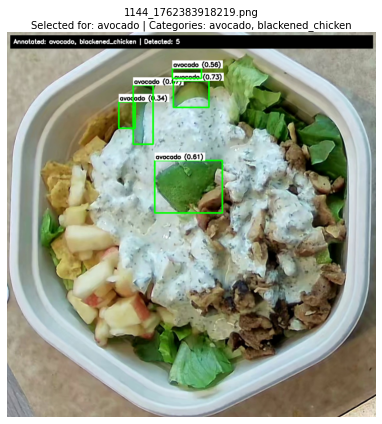


1144_1762383918219.png:
  Selected for ingredient: avocado
  Annotated categories: ['avocado', 'blackened_chicken']
  Detection prompts used: ['avocado', 'chicken chunks']
  Detected labels: {'avocado'}
  Total detections: 5
  Number of annotations in JSON: 2
  ⚠️  MISSING DETECTIONS: ['blackened_chicken']
--------------------------------------------------------------------------------


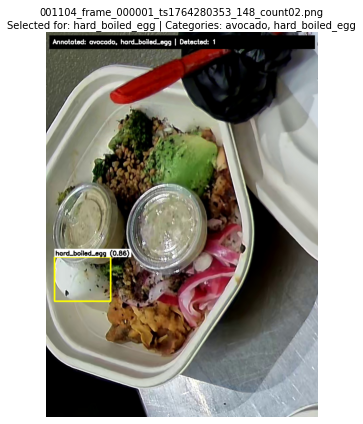


001104_frame_000001_ts1764280353_148_count02.png:
  Selected for ingredient: hard_boiled_egg
  Annotated categories: ['avocado', 'hard_boiled_egg']
  Detection prompts used: ['avocado', 'egg']
  Detected labels: {'hard_boiled_egg'}
  Total detections: 1
  Number of annotations in JSON: 2
  ⚠️  MISSING DETECTIONS: ['avocado']
--------------------------------------------------------------------------------


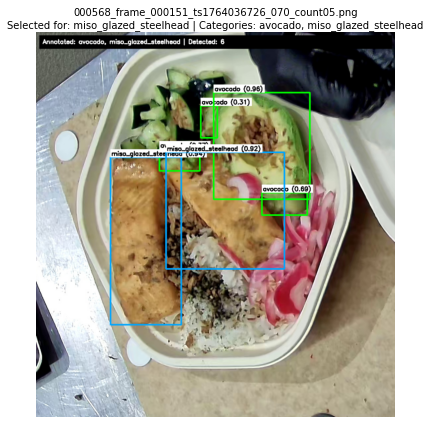


000568_frame_000151_ts1764036726_070_count05.png:
  Selected for ingredient: miso_glazed_steelhead
  Annotated categories: ['avocado', 'miso_glazed_steelhead']
  Detection prompts used: ['avocado', 'cooked salmon fillet']
  Detected labels: {'miso_glazed_steelhead', 'avocado'}
  Total detections: 6
  Number of annotations in JSON: 2
  ✓ All annotated categories have detections
--------------------------------------------------------------------------------


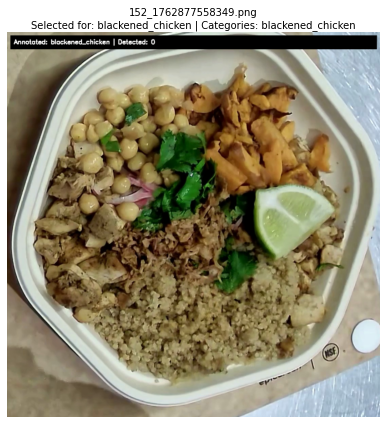


152_1762877558349.png:
  Selected for ingredient: blackened_chicken
  Annotated categories: ['blackened_chicken']
  Detection prompts used: ['chicken chunks']
  Detected labels: set()
  Total detections: 0
  Number of annotations in JSON: 1
  ⚠️  MISSING DETECTIONS: ['blackened_chicken']
--------------------------------------------------------------------------------


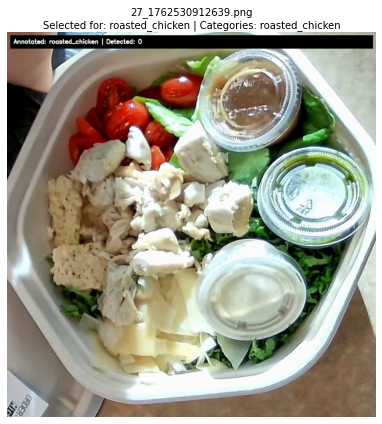


27_1762530912639.png:
  Selected for ingredient: roasted_chicken
  Annotated categories: ['roasted_chicken']
  Detection prompts used: ['chicken chunks']
  Detected labels: set()
  Total detections: 0
  Number of annotations in JSON: 1
  ⚠️  MISSING DETECTIONS: ['roasted_chicken']
--------------------------------------------------------------------------------


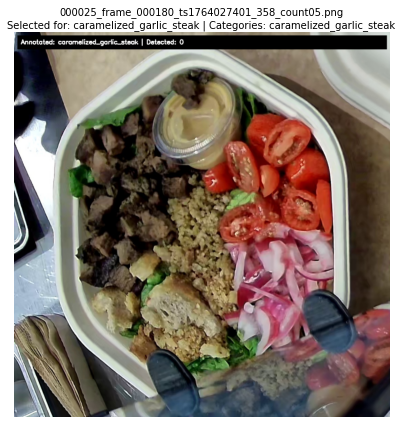


000025_frame_000180_ts1764027401_358_count05.png:
  Selected for ingredient: caramelized_garlic_steak
  Annotated categories: ['caramelized_garlic_steak']
  Detection prompts used: ['steak']
  Detected labels: set()
  Total detections: 0
  Number of annotations in JSON: 1
  ⚠️  MISSING DETECTIONS: ['caramelized_garlic_steak']
--------------------------------------------------------------------------------


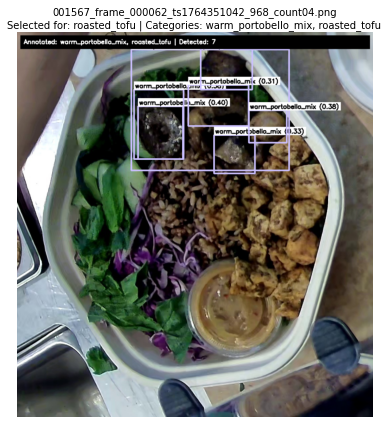


001567_frame_000062_ts1764351042_968_count04.png:
  Selected for ingredient: roasted_tofu
  Annotated categories: ['warm_portobello_mix', 'roasted_tofu']
  Detection prompts used: ['dark mushroom mix', 'tofu cube']
  Detected labels: {'warm_portobello_mix'}
  Total detections: 7
  Number of annotations in JSON: 2
  ⚠️  MISSING DETECTIONS: ['roasted_tofu']
--------------------------------------------------------------------------------


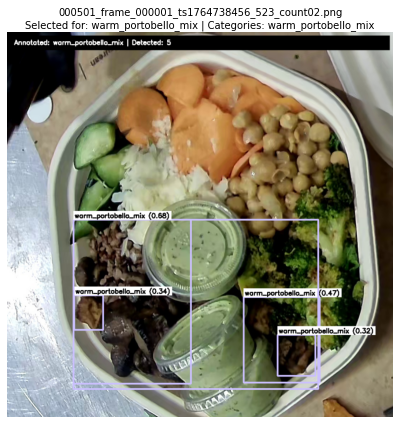


000501_frame_000001_ts1764738456_523_count02.png:
  Selected for ingredient: warm_portobello_mix
  Annotated categories: ['warm_portobello_mix']
  Detection prompts used: ['dark mushroom mix']
  Detected labels: {'warm_portobello_mix'}
  Total detections: 5
  Number of annotations in JSON: 1
  ✓ All annotated categories have detections
--------------------------------------------------------------------------------


In [156]:
def draw_detections(img, detections, annotated_categories):
    """Draw bounding boxes and labels on image."""
    img_copy = img.copy()
    
    # Color map for bounding boxes (BGR for OpenCV)
    label_colors_bgr = {
        "avocado": (0, 255, 0),           # Green
        "blackened_chicken": (255, 0, 0),  # Blue
        "roasted_chicken": (255, 0, 0),    # Blue
        "egg": (0, 255, 255),             # Yellow
        "steak": (0, 0, 255),             # Red
        "salmon": (255, 165, 0),          # Orange
        "roasted_tofu": (128, 0, 128),    # Purple
        "warm_portobello_mix": (255, 192, 203),  # Pink
        "hard_boiled_egg": (0, 255, 255),  # Yellow
        "caramelized_garlic_steak": (0, 0, 255),  # Red
        "miso_glazed_steelhead": (255, 165, 0),  # Orange
    }
    default_color_bgr = (255, 255, 255)  # White for unknown
    
    # Draw bounding boxes
    for det in detections:
        label = det.get('label', 'unknown')
        box = det.get('box', [])
        score = det.get('score', 0.0)
        
        if len(box) == 4:
            x1, y1, x2, y2 = box
            color = label_colors_bgr.get(label.lower(), default_color_bgr)
            
            # Draw rectangle
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, 3)
            
            # Add label with score
            label_text = f"{label} ({score:.2f})"
            
            (text_width, text_height), baseline = cv2.getTextSize(
                label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2
            )
            
            cv2.rectangle(img_copy, 
                         (x1, y1 - text_height - 10),
                         (x1 + text_width + 6, y1),
                         (255, 255, 255), -1)
            
            cv2.putText(img_copy, label_text, (x1 + 3, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)
    
    # Add info text at the top
    h, w = img_copy.shape[:2]
    info_text = f"Annotated: {', '.join(annotated_categories)} | Detected: {len(detections)}"
    cv2.rectangle(img_copy, (10, 10), (w - 10, 50), (0, 0, 0), -1)
    cv2.putText(img_copy, info_text, (20, 35),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    return img_copy

# Visualize all results
for result in results:
    img_with_detections = draw_detections(
        result["image"], 
        result["detections"],
        result["annotated_categories"]
    )
    
    # Convert BGR to RGB for visualization
    img_rgb = cv2.cvtColor(img_with_detections, cv2.COLOR_BGR2RGB)
    
    # Resize image to reduce file size (max width 800px, maintain aspect ratio)
    max_width = 800
    h, w = img_rgb.shape[:2]
    if w > max_width:
        scale = max_width / w
        new_w = max_width
        new_h = int(h * scale)
        img_rgb = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Display with small figure size to reduce notebook file size
    plt.figure(figsize=(8, 6), dpi=72)  # Reduced size and lower DPI
    plt.imshow(img_rgb)
    plt.axis('off')
    # Build title with target ingredient info
    target_ingredient = result.get('target_ingredient', 'N/A')
    title = f"{result['path'].name}\nSelected for: {target_ingredient} | Categories: {', '.join(result['annotated_categories'])}"
    plt.title(title, fontsize=10, pad=5)  # Reduced font size
    plt.tight_layout()
    plt.show()
    
    target_ingredient = result.get('target_ingredient', 'N/A')
    missing_categories = result.get('missing_categories', [])
    print(f"\n{result['path'].name}:")
    print(f"  Selected for ingredient: {target_ingredient}")
    print(f"  Annotated categories: {result['annotated_categories']}")
    print(f"  Detection prompts used: {result['prompts']}")
    print(f"  Detected labels: {result['detected_labels']}")
    print(f"  Total detections: {len(result['detections'])}")
    print(f"  Number of annotations in JSON: {len(result['annotations'])}")
    if missing_categories:
        print(f"  ⚠️  MISSING DETECTIONS: {missing_categories}")
    else:
        print(f"  ✓ All annotated categories have detections")
    print("-" * 80)
